# Ejercicio 1.
Genera una imagen semejante a un tablero de ajedrez tomando en cuenta que cada casilla debe medir
100x100 px como se muestra en la imagen a continuación (toma encuenta la saturación de los colores)

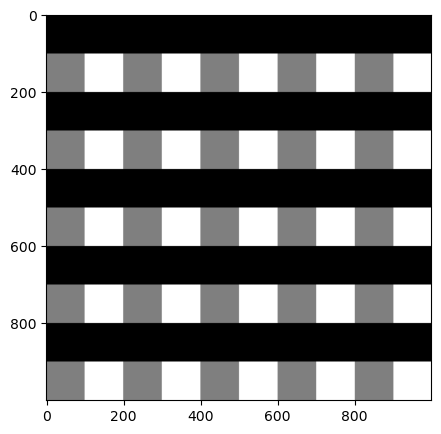

In [50]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

plt.rcParams['figure.figsize'] = [10, 5]
imgSize = 1000

R = np.ones((imgSize, imgSize)) * 255
G = np.ones((imgSize, imgSize)) * 255
B = np.ones((imgSize, imgSize)) * 255

saturacion = 0.5

for i in range(imgSize):
  for j in range(imgSize):
    if i // 100 % 2 == 0:
      R[i][j] = 0
      G[i][j] = 0
      B[i][j] = 0
    if j // 100 % 2 == 0:
      R[i][j] = int(R[i][j] * saturacion)
      G[i][j] = int(G[i][j] * saturacion)
      B[i][j] = int(B[i][j] * saturacion)

img = np.dstack((R, G, B))
img = np.array(img, dtype=int)

plt.figure()
plt.imshow(img)

cv2.imwrite('images/tablero1.png', img)
plt.show()

# Ejercicio 2.
Genera una imagen como la de referencia.

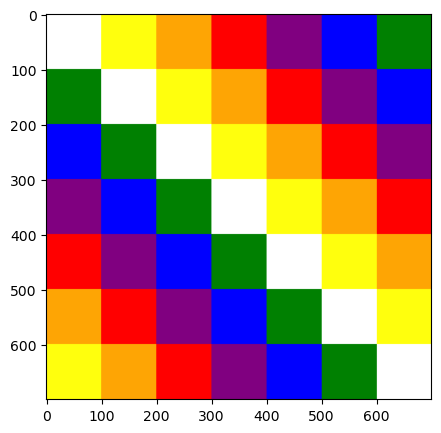

In [51]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

plt.rcParams['figure.figsize'] = [10, 5]
imgSize = 700

R = np.ones((imgSize, imgSize)) * 255
G = np.ones((imgSize, imgSize)) * 255
B = np.ones((imgSize, imgSize)) * 255

colores = [(255, 255, 255), (255, 255, 13), (254, 165, 4), (255, 0, 0), (128, 0, 128), (0, 0, 255), (0, 128, 1)]

saturacion = 0.5

for i in range(imgSize):
  for j in range(imgSize):
    x = i // 100
    y = j // 100
    
    indiceColor = (7 - x + y) % 7
    
    R[i][j] = colores[indiceColor][0]
    G[i][j] = colores[indiceColor][1]
    B[i][j] = colores[indiceColor][2]

img = np.dstack((R, G, B))
img = np.array(img, dtype=int)

plt.figure()
plt.imshow(img)

cv2.imwrite('images/img2-whipala.jpeg', img)
plt.show()

# Ejercicio 3.
Haciendo uso de la imagen1.jpg obtiene el siguiente resultado

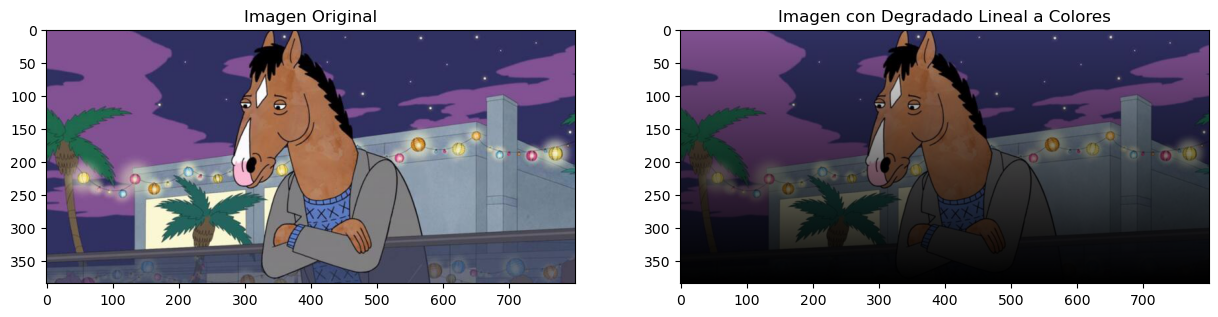

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

img = cv2.imread('./images/img1.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Crear un degradado del mismo tamaño que la imagen
height, width = img.shape[:2]
gradient = np.zeros((height, width), dtype=np.float32)

# Degradado vertical (de arriba hacia abajo)
for y in range(height):
  gradient[y, :] = 1 - y / height

# Crear máscara con el degradado
mask = gradient[:, :, np.newaxis]  # Añadir dimensión para multiplicar con la imagen

# Aplicar el degradado (transparencia gradual)
result = img * mask

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(result.astype(np.uint8))
plt.title('Imagen con Degradado Lineal a Colores')

plt.show()

plt.imsave('./images/img3-degradado.jpg', result.astype(np.uint8))

# Ejercicio 4.
Haciendo uso de la imagen1.jpg obtiene el siguiente resultado.

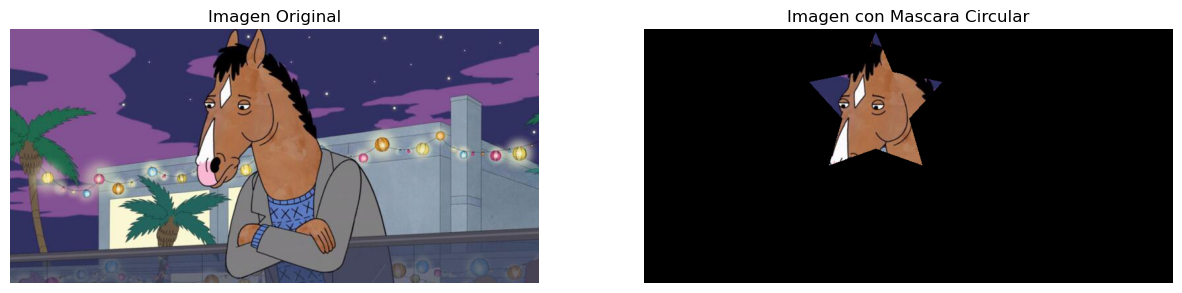

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagenColor = cv2.cvtColor(cv2.imread('./images/img1.jpeg'), cv2.COLOR_BGR2RGB)
imagen = cv2.imread('./images/img1.jpeg', 0)

alto, ancho = imagen.shape # Obtener dimensiones de la imagen

mascara = np.zeros_like(imagen) 
centro = (350, 105) # Centro de la mascara

cX = centro[0]
cY = centro[1]

puntosEstrella = np.array([[cX, cY - 100],
                           [cX + 25, cY - 40],
                           [cX + 100, cY - 25],
                           [cX + 50, cY + 30],
                           [cX + 70, cY + 100],
                           [cX, cY + 75],
                           [cX - 70, cY + 100],
                           [cX - 50, cY + 30],
                           [cX - 100, cY - 25],
                           [cX - 25, cY - 40]], np.int32)

cv2.fillPoly(mascara, [puntosEstrella], (255)) # Crear mascara de estrella

imagen_mascara = cv2.bitwise_and(imagenColor, imagenColor, mask=mascara) # Aplicar mascara a la imagen

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(imagenColor)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_mascara, cmap='gray')
plt.title('Imagen con Mascara Circular')
plt.axis('off')

plt.show()
plt.imsave('./images/img4-recorte-estrella.jpeg', imagen_mascara)

# Ejercicio 5.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), genera su
histograma por canales, solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de
preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes
titulos, guarda todas las imágenes resultantes con sus nombres.

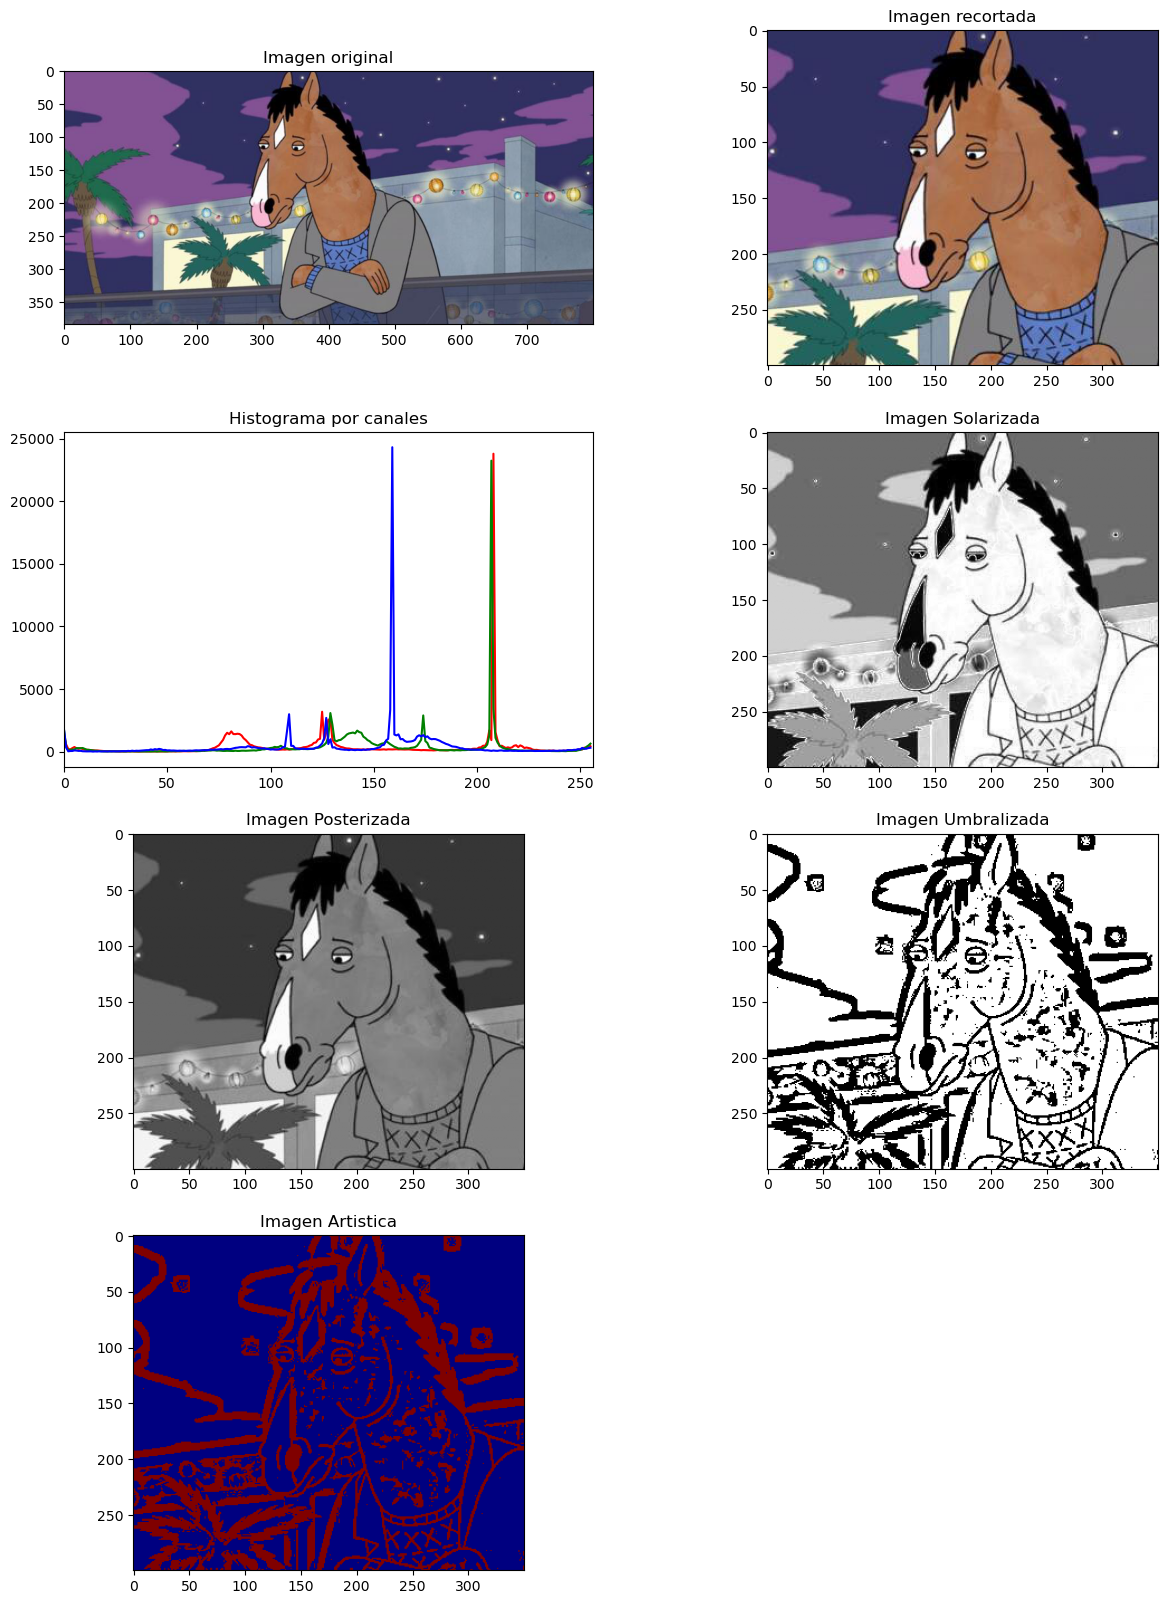

In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

img = cv2.imread('./images/img1.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

alto, ancho = cv2.imread('./images/img1.jpeg', 0).shape # 384 x 800

xi = random.randint(0, ancho - 350)
xf = xi + 350
yi = random.randint(0, alto - 300)
yf = yi + 300

imgRecortada = img[yi:yf, xi:xf]

# Guardar la imagen seccionada
img_cortada = img[yi:yf, xi:xf, :]
plt.imsave('./images/imagen_cortada5.jpeg', img_cortada) # Guardar imagen

# Histograma de canales
seccionada = plt.imread('./images/imagen_cortada5.jpeg') # Lectura rgb
color = ('r', 'g', 'b')

# Solarizacion
def solarizar(imagen, umbral):
  imagen_solarizada = np.where(imagen < umbral, imagen, 255 - imagen)
  return imagen_solarizada

img_gris = cv2.cvtColor(imgRecortada, cv2.COLOR_RGB2GRAY)
imgSolarizada = solarizar(img_gris, 127)

# Posterizacion
def posterizar(imagen, nivel):
  factor = 255 / nivel
  imagen_posterizada = np.round((imagen / factor) * factor)
  return imagen_posterizada.astype(np.uint8)

imgPosterizada = posterizar(img_gris, 4)

# Umbralizacion
v = 15
factor = 2
imgUmbral = cv2.adaptiveThreshold(img_gris, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, v, factor)

# Imagen artistica
imgArtistica = cv2.applyColorMap(imgUmbral, cv2.COLORMAP_JET)

plt.figure(figsize=(15, 20))

plt.subplot(4, 2, 1)
plt.imshow(img)
plt.title('Imagen original')

plt.subplot(4, 2, 2)
plt.imshow(imgRecortada)
plt.title('Imagen recortada')

plt.subplot(4, 2, 3)
plt.title('Histograma por canales')
for canal, col in enumerate(color):
  histograma = cv2.calcHist([seccionada * 255], [canal], None, [256], [0, 256]) # Histograma
  plt.plot(histograma, color=col) # Graficar histograma
  plt.xlim([0, 256]) # Limitar el eje x

plt.subplot(4, 2, 4)
plt.imshow(imgSolarizada, cmap='gray')
plt.title('Imagen Solarizada')

plt.subplot(4, 2, 5)
plt.imshow(imgPosterizada, cmap='gray')
plt.title('Imagen Posterizada')

plt.subplot(4, 2, 6)
plt.imshow(imgUmbral, cmap='gray')
plt.title('Imagen Umbralizada')

plt.subplot(4, 2, 7)
plt.imshow(imgArtistica)
plt.title('Imagen Artistica')

plt.show()

plt.imsave('./images/img5-recortada.jpeg', imgRecortada)
plt.imsave('./images/img5-solarizada.jpeg', imgSolarizada)
plt.imsave('./images/img5-posterizada.jpeg', imgPosterizada)
plt.imsave('./images/img5-umbralizada.jpeg', imgUmbral)
plt.imsave('./images/img5-artistica.jpeg', imgArtistica)

# Teoria:
### ¿A que nos referimos si hablamos de una imagen digital?
Una imagen digital es la representacion de bits de informacion de color en un arreglo
bidimensional.
### ¿Qué es la profundidad del color?
La profundidad de color es la cantidad de bits de informacion que podemos representar
en cada pixel de una imagen digital.
### ¿Cuál es la diferencia entre CMKY y RGB?
El CMKY se utiliza para la impresion de imagenes y el RGB para trabajar las imagenes en digital.